In [ ]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


import import_ipynb
import nbimporter
from utils import prepareTrainingSet3Sec,standardization,Grafico_Before_After_Standardization,Grafico_Tre_Valori,evaluate_Model, encode_labels, ConfusionMatrix# type: ignore



3 secondi


In [5]:
X_train, X_test, y_train, y_test= prepareTrainingSet3Sec()

knn=KNeighborsClassifier(n_neighbors=3)

# Addestriamo il modello

knn.fit(X_train, y_train)

# Prediciamo sul set di test
y_pred = knn.predict(X_test)

y_pred = knn.predict(X_test)
before_standardization= accuracy_score(y_test, y_pred)
y_pred_train = knn.predict(X_train)
evaluate_Model(y_test, y_pred,y_train, y_pred_train)

---------STATISTICHE TEST----------
Accuratezza: 0.2548
Precision: 0.2689
Recall: 0.2540
F1-score: 0.2495
F2-score: 0.2497
---------STATISTICHE TRAING----------
Accuratezza: 0.5533
Precision: 0.5950
Recall: 0.5536
F1-score: 0.5449
F2-score: 0.5440

=== Analisi ===
Il modello sembra bilanciato e generalizza bene.


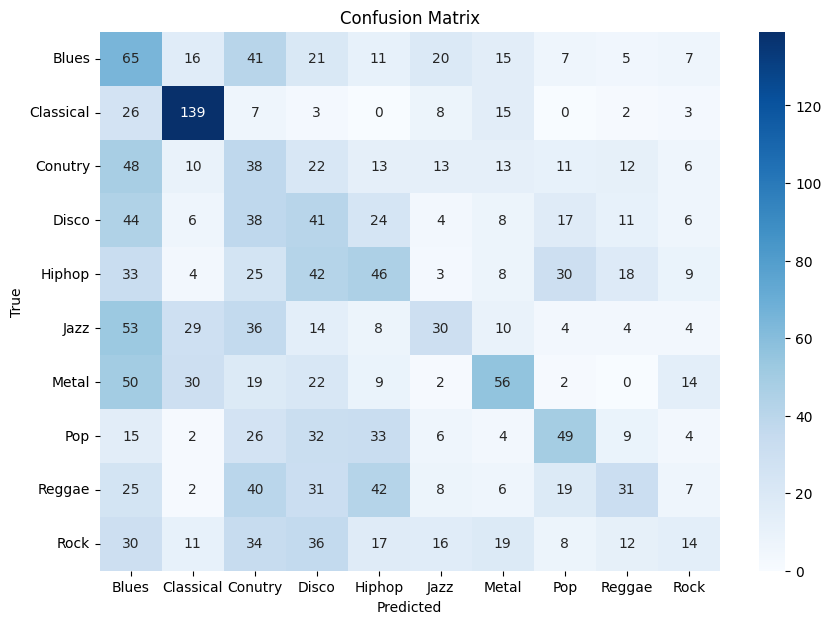

In [6]:
ConfusionMatrix(y_test, y_pred)

In [3]:

X_train, X_test, y_train, y_test= prepareTrainingSet3Sec()
X_train, X_test= standardization(X_train, X_test)


model = KNeighborsClassifier(n_neighbors=5)
# Addestriamo il modello
model.fit(X_train, y_train)

# Prediciamo sul set di test
y_pred = model.predict(X_test)
after_standardization= accuracy_score(y_test, y_pred)
y_pred_train = model.predict(X_train)
evaluate_Model(y_test, y_pred,y_train, y_pred_train)

c:\Users\romeo\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\romeo\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


---------STATISTICHE TEST----------
Accuratezza: 0.9019
Precision: 0.9024
Recall: 0.9010
F1-score: 0.9010
F2-score: 0.9008
---------STATISTICHE TRAING----------
Accuratezza: 0.9364
Precision: 0.9374
Recall: 0.9366
F1-score: 0.9365
F2-score: 0.9365

=== Analisi ===
Il modello potrebbe soffrire di OVERFITTING (performance molto migliore sul training set).


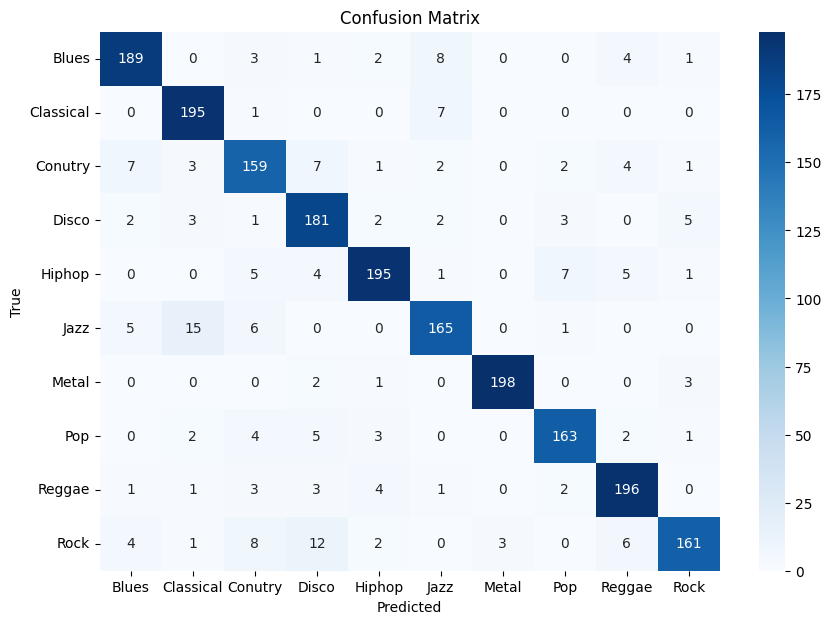

In [4]:

ConfusionMatrix(y_test, y_pred)

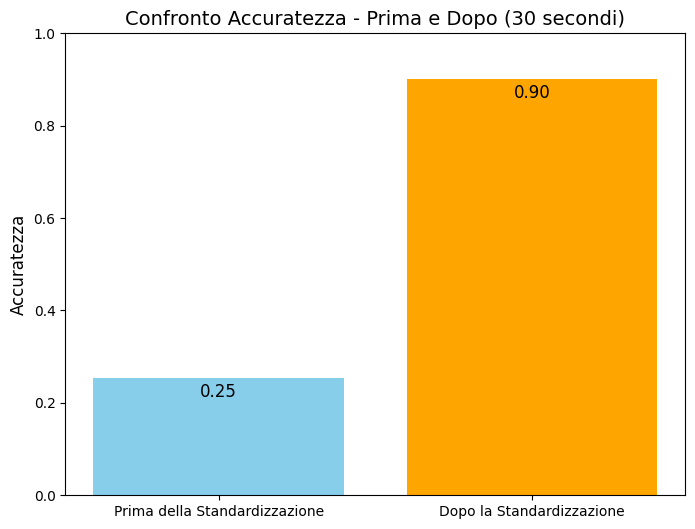

In [9]:
Grafico_Before_After_Standardization(before_standardization, after_standardization)

In [7]:
# Supponiamo che prepareTrainingSet3Sec, encode_labels e standardization siano definite altrove
X_train, X_test, y_train, y_test = prepareTrainingSet3Sec()
y_train, y_test, label_encoder = encode_labels(y_train, y_test)
X_train, X_test = standardization(X_train, X_test)

# Definisci il modello
model = KNeighborsClassifier()

# Definisci la griglia dei parametri per GridSearchCV
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Esegui GridSearchCV
grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Filtra i modelli con differenza di accuracy entro il 10%
valid_models = []
for params in grid_search.cv_results_['params']:
    model.set_params(**params)
    model.fit(X_train, y_train)
    train_accuracy = accuracy_score(y_train, model.predict(X_train))
    test_accuracy = accuracy_score(y_test, model.predict(X_test))
    if abs(train_accuracy - test_accuracy) <= 0.10 and train_accuracy < 0.99:
        valid_models.append((model, params, train_accuracy, test_accuracy))


# Trova il miglior modello tra quelli validi
if valid_models:
    best_model, best_params, best_train_accuracy, best_test_accuracy = max(valid_models, key=lambda x: x[3])
    knn={best_test_accuracy}
    print(f"Training Accuracy: {best_train_accuracy}")
    print(f"Testing Accuracy: {best_test_accuracy}")
    print(f"Best Parameters: {best_params}")
    print("La differenza tra l'accuracy di training e di test è entro il 10%.")
else:
    print("Nessun modello ha una differenza di accuracy entro il 10%.")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Training Accuracy: 0.9707207207207207
Testing Accuracy: 0.9269269269269269
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
La differenza tra l'accuracy di training e di test è entro il 10%.


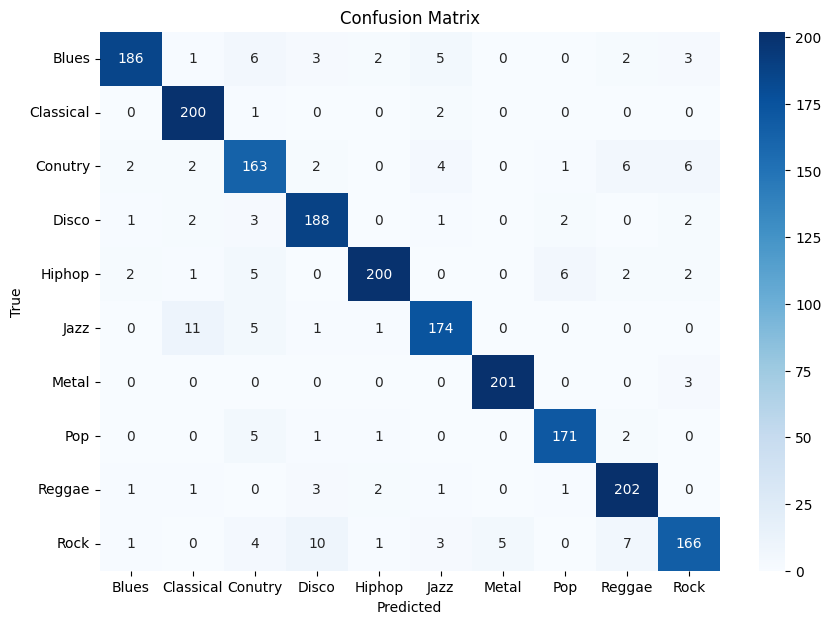

In [10]:
y_pred = best_model.predict(X_test)
ConfusionMatrix(y_test, y_pred)

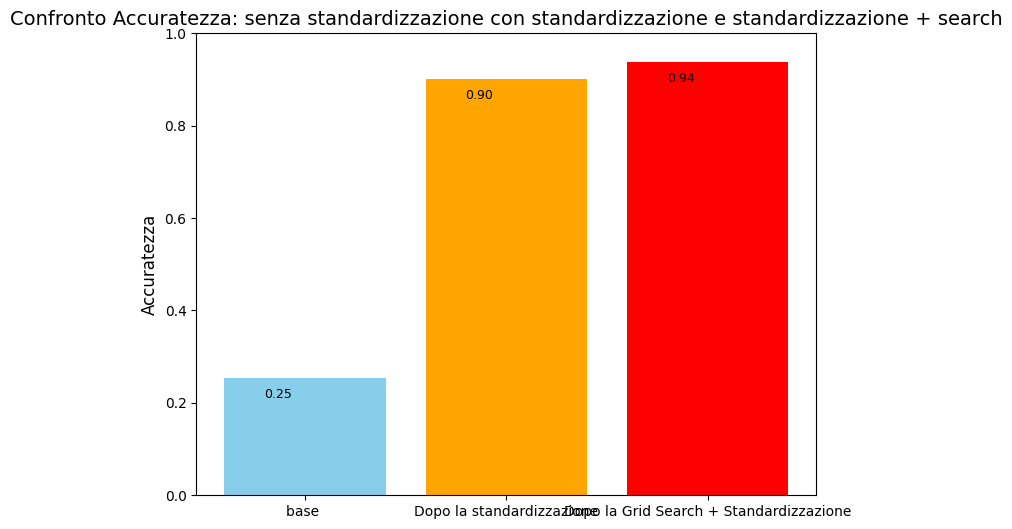

In [16]:
Grafico_Tre_Valori(before_standardization, after_standardization, after_grid)